<center><a href="https://github.com/CyConProject?tab=repositories"><img src="https://github.com/CyConProject/Lab/blob/main/Figures/CyCon.png?raw=true" alt="CyCon logo" width="80"></a></center>

## Module 3-6 Lab: Concrete Crack Image Classification with Keras

Can a network tell whether a **concrete-surface image contains a visible crack**? In this lab you will use real concrete images from the [Concrete Crack Images for Classification dataset on Kaggle](https://www.kaggle.com/datasets/arnavr10880/concrete-crack-images-for-classification). The two image folders represent **Negative** (no visible crack) and **Positive** (visible crack).

This image-classification lab follows **Module 3-5 (building classifiers in Keras)**. It preserves the eight-part format of **Module 3 Regression Projects with Keras**, with short exercises, expandable solutions, and a runnable reference cell after each exercise.

### Objectives

1. Inspect labeled concrete images and distinguish binary classification from regression.
2. Download images, identify class folders, and form separate train, validation, and test partitions.
3. Resize and scale images, then train a small `Sequential` Keras classifier.
4. Read crack probabilities, accuracy, and class-specific errors.
5. Compare a dense network with a small convolutional network.
6. Explain why image-only predictions cannot assess structural safety or crack severity.

**Time:** approximately 60–90 minutes (download and training time vary). **Runtime:** Google Colab is recommended; CPU also works with the classroom subset. The notebook downloads the dataset when first run. If you already have the dataset, set `DATA_DIR` to the directory containing the downloaded files in Part I.

**How to work:** Attempt each `# To Do` cell, then expand its solution if needed. Each following *reference implementation* cell allows the notebook to run from top to bottom.

## 1. Recap: Why Keras for Image Classification?

Regression predicts a numerical measurement, such as concrete strength in MPa. **Binary classification** chooses between two categories. Here `0` means **no visible crack** and `1` means **visible crack** in a cropped image. This does not tell us crack width, cause, depth, or structural significance.

The module video uses softmax for several mutually exclusive classes. For **two** classes, we can instead use a single **sigmoid** output. A score near 1 favors the crack class; a score near 0 favors the no-crack class. We train with **binary cross-entropy**, use **Adam**, and track **accuracy**. We will also examine **recall for cracked images** and a confusion matrix because missing cracks can matter in an inspection workflow.

A dense model will first flatten the images. In Part VI, a small convolutional neural network (CNN) will preserve local spatial patterns and offer a useful comparison.

## 2. Part I – Setup and Data Loading

The Kaggle dataset is distributed with class folders commonly called `Positive` and `Negative`. Download through the `kagglehub` command provided in the lab instructions. This notebook discovers those folders even when they are nested under another directory; it does not assume a fixed download location.

| Class folder | Numerical label | Meaning for this lab |
|---|---:|---|
| `Negative` | 0 | No visible crack in the cropped image |
| `Positive` | 1 | Visible crack in the cropped image |

**Download note:** `kagglehub` caches the data after its first download. Some environments may ask you to accept dataset terms or authenticate. If the download is unavailable, download the same Kaggle dataset yourself and set `DATA_DIR` below to its extracted directory. There is no need to upload it separately for this notebook to work in a normal Colab session.

In [1]:
# Uncomment if these packages are missing in your notebook environment:
# %pip install -q tensorflow kagglehub scikit-learn pandas matplotlib

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Rescaling
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

tf.keras.utils.set_random_seed(42)
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


In [2]:
# Set this to an extracted dataset directory if you already downloaded it.
# Example: DATA_DIR = "/content/concrete-crack-images"
DATA_DIR = None

if DATA_DIR is None:
    import kagglehub
    DATA_DIR = kagglehub.dataset_download("arnavr10880/concrete-crack-images-for-classification")
root = Path(DATA_DIR).expanduser()
if not root.is_dir():
    raise FileNotFoundError(f"Dataset directory does not exist: {root}")
print("Path to dataset files:", root)

100%|██████████| 233M/233M [00:04<00:00, 56.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/arnavr10880/concrete-crack-images-for-classification/versions/1


### 2.1 Find and inspect the images

The dataset folder can include one or more outer directories, so search for sibling `Positive` and `Negative` folders. Keep the discovered class mapping fixed throughout the notebook. Check the example labels visually: real image datasets can contain ambiguous marks or imperfect labels. Use common image suffixes and ignore unrelated files.

> **Exercise 1:** Print the path to the two image folders and the number of readable image filenames in each. Then display at least one image per class.

In [3]:
# To Do
# Search root.rglob("*") for a parent containing both class subfolders.
# Count image files in each folder.
# Display a cracked and an uncracked example.

<details><summary>Solution to Exercise 1 (click to expand)</summary>

```python
pairs = []
for parent in [root, *root.rglob("*")]:
    if parent.is_dir():
        children = {child.name.lower(): child for child in parent.iterdir() if child.is_dir()}
        if {"negative", "positive"} <= children.keys():
            pairs.append((children["negative"], children["positive"]))
print("Possible class folders:", pairs)
```

Use the reference cell next to build a class table and display images.

</details>

Negative folder: /root/.cache/kagglehub/datasets/arnavr10880/concrete-crack-images-for-classification/versions/1/Negative | images: 20000
Positive folder: /root/.cache/kagglehub/datasets/arnavr10880/concrete-crack-images-for-classification/versions/1/Positive | images: 20000


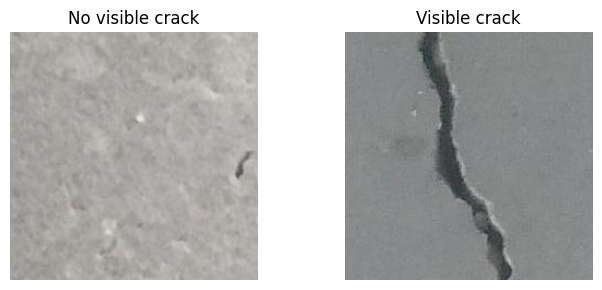

In [4]:
# Reference implementation: discover folders, count images, and show samples
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp", ".gif"}
pairs = []
for parent in [root, *root.rglob("*")]:
    if parent.is_dir():
        children = {child.name.lower(): child for child in parent.iterdir() if child.is_dir()}
        if {"negative", "positive"} <= children.keys():
            pairs.append((children["negative"], children["positive"]))
if not pairs:
    raise FileNotFoundError("Could not find sibling Positive/Negative folders under DATA_DIR.")
# Choose the pair with the most supported image files when multiple copies exist.
def image_paths(folder):
    return sorted(p for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_SUFFIXES)
negative_dir, positive_dir = max(pairs, key=lambda pair: sum(len(image_paths(p)) for p in pair))
paths_by_class = {0: image_paths(negative_dir), 1: image_paths(positive_dir)}
print("Negative folder:", negative_dir, "| images:", len(paths_by_class[0]))
print("Positive folder:", positive_dir, "| images:", len(paths_by_class[1]))
if min(map(len, paths_by_class.values())) < 50:
    raise ValueError("At least one class has fewer than 50 supported image files; check DATA_DIR.")
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
for ax, label in zip(axes, [0, 1]):
    image = tf.keras.utils.load_img(paths_by_class[label][0])
    ax.imshow(image)
    ax.set_title("No visible crack" if label == 0 else "Visible crack")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 3. Part II – Split and Prepare the Images

The full image dataset can be large. For a manageable classroom run, draw up to **1,000 images per class**, then reserve 40% and split that portion equally between validation and testing (60% / 20% / 20%). The random seed makes the subset reproducible; labels are stratified in each split.

Resize every image to **64 × 64** and retain RGB channels. The model will divide pixel values by 255 inside the network. The test partition must stay out of model selection. **Caution:** image patches from the same source photograph or structure may be related. A random patch split can overstate performance on a completely new site; evaluate by structure or source image if those identifiers become available.

> **Exercise 2:** Select a balanced subset, split it into train/validation/test, and verify counts for each class.

In [5]:
# To Do
# rng = np.random.default_rng(42)
# Select up to 1,000 file paths in each class without replacement.
# Use train_test_split(..., stratify=labels) twice.
# Print class counts for each partition.

<details><summary>Solution to Exercise 2 (click to expand)</summary>

```python
rng = np.random.default_rng(42)
selected = []
labels = []
for label in (0, 1):
    choices = rng.choice(paths_by_class[label], size=min(1000, len(paths_by_class[label])), replace=False)
    selected.extend(str(p) for p in choices)
    labels.extend([label] * len(choices))
train_paths, other_paths, y_train, other_labels = train_test_split(
    selected, labels, test_size=0.40, random_state=42, stratify=labels
)
val_paths, test_paths, y_val, y_test = train_test_split(
    other_paths, other_labels, test_size=0.50, random_state=42, stratify=other_labels
)
```

</details>

In [6]:
# Reference implementation: balanced subsample and disjoint partitions
rng = np.random.default_rng(42)
selected, labels = [], []
for label in (0, 1):
    choices = rng.choice(paths_by_class[label], size=min(1000, len(paths_by_class[label])), replace=False)
    selected.extend(str(p) for p in choices)
    labels.extend([label] * len(choices))
train_paths, other_paths, y_train, other_labels = train_test_split(
    selected, labels, test_size=0.40, random_state=42, stratify=labels
)
val_paths, test_paths, y_val, y_test = train_test_split(
    other_paths, other_labels, test_size=0.50, random_state=42, stratify=other_labels
)
for name, paths, y in [("Train", train_paths, y_train), ("Validation", val_paths, y_val), ("Test", test_paths, y_test)]:
    print(name, len(paths), pd.Series(y).value_counts().sort_index().to_dict())
assert not (set(train_paths) & set(val_paths) | set(train_paths) & set(test_paths) | set(val_paths) & set(test_paths))

Train 1200 {0: 600, 1: 600}
Validation 400 {0: 200, 1: 200}
Test 400 {0: 200, 1: 200}


In [7]:
IMAGE_SIZE = (64, 64)
BATCH_SIZE = 32

def decode_image(path, label):
    content = tf.io.read_file(path)
    image = tf.io.decode_image(content, channels=3, expand_animations=False)
    image.set_shape((None, None, 3))
    image = tf.image.resize(image, IMAGE_SIZE)
    return image, tf.cast(label, tf.float32)

def make_dataset(paths, labels, training=False):
    ds = tf.data.Dataset.from_tensor_slices((list(paths), np.asarray(labels, dtype="float32")))
    if training:
        ds = ds.shuffle(len(paths), seed=42, reshuffle_each_iteration=True)
    return ds.map(decode_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_paths, y_train, training=True)
val_ds = make_dataset(val_paths, y_val)
test_ds = make_dataset(test_paths, y_test)
images_batch, labels_batch = next(iter(train_ds))
print("Image batch:", images_batch.shape, "Labels:", labels_batch.shape)
assert images_batch.shape[1:] == (64, 64, 3)

Image batch: (32, 64, 64, 3) Labels: (32,)


## 4. Part III – Build a Binary Image Classifier in Keras

Start with a dense network so its connection to the lesson is clear. `Flatten` turns each image into a vector; two hidden `Dense` layers use ReLU, and a **single sigmoid output** represents the crack class. `Rescaling(1./255)` ensures the same preprocessing happens for training and later predictions.

> **Exercise 3:** Finish `build_dense_classifier()`. Use hidden layers of **64** and **32** units, `binary_crossentropy`, Adam, and accuracy.

In [8]:
# To Do
# def build_dense_classifier():
#     model = Sequential([...])
#     model.compile(...)
#     return model

<details><summary>Solution to Exercise 3 (click to expand)</summary>

```python
def build_dense_classifier():
    model = Sequential([
        Input(shape=(64, 64, 3)), Rescaling(1.0 / 255), Flatten(),
        Dense(64, activation="relu"), Dense(32, activation="relu"),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model
```

</details>

In [9]:
# Reference implementation: baseline model
def build_dense_classifier():
    model = Sequential([
        Input(shape=(64, 64, 3)), Rescaling(1.0 / 255), Flatten(),
        Dense(64, activation="relu"), Dense(32, activation="relu"),
        Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

dense_model = build_dense_classifier()
dense_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       786,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 788,609 (3.01 MB)

 Trainable params: 788,609 (3.01 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Part IV – Train and Read Validation Results

Train the dense network for **8 epochs** using the training partition. Look at training and validation curves before selecting a final model. The test images are kept aside until Part VI.

In [10]:
dense_history = dense_model.fit(train_ds, validation_data=val_ds, epochs=8, verbose=2)
print(pd.DataFrame(dense_history.history).tail(3).round(3))

Epoch 1/8
38/38 - 3s - 67ms/step - accuracy: 0.5233 - loss: 0.9563 - val_accuracy: 0.4975 - val_loss: 0.7289
Epoch 2/8
38/38 - 2s - 45ms/step - accuracy: 0.5917 - loss: 0.6545 - val_accuracy: 0.4725 - val_loss: 0.6565
Epoch 3/8
38/38 - 2s - 57ms/step - accuracy: 0.5675 - loss: 0.6896 - val_accuracy: 0.7600 - val_loss: 0.5666
Epoch 4/8
38/38 - 1s - 28ms/step - accuracy: 0.6292 - loss: 0.6325 - val_accuracy: 0.4850 - val_loss: 0.6452
Epoch 5/8
38/38 - 1s - 32ms/step - accuracy: 0.6750 - loss: 0.5715 - val_accuracy: 0.7575 - val_loss: 0.5527
Epoch 6/8
38/38 - 1s - 34ms/step - accuracy: 0.7517 - loss: 0.5298 - val_accuracy: 0.7325 - val_loss: 0.5464
Epoch 7/8
38/38 - 1s - 29ms/step - accuracy: 0.6633 - loss: 0.5695 - val_accuracy: 0.7800 - val_loss: 0.5203
Epoch 8/8
38/38 - 1s - 33ms/step - accuracy: 0.7617 - loss: 0.4934 - val_accuracy: 0.5925 - val_loss: 0.5586
   accuracy   loss  val_accuracy  val_loss
5     0.752  0.530         0.733     0.546
6     0.663  0.570         0.780     0.520

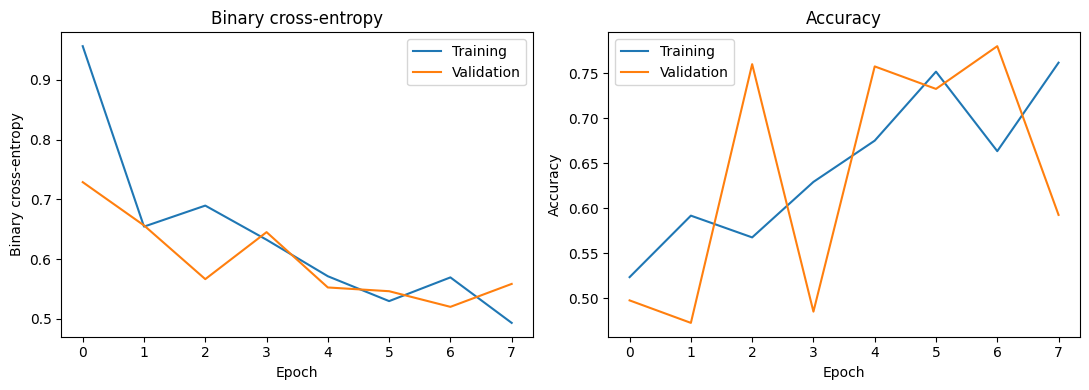

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric, label in zip(axes, ["loss", "accuracy"], ["Binary cross-entropy", "Accuracy"]):
    ax.plot(dense_history.history[metric], label="Training")
    ax.plot(dense_history.history["val_" + metric], label="Validation")
    ax.set(title=label, xlabel="Epoch", ylabel=label)
    ax.legend()
plt.tight_layout()
plt.show()

> **Exercise 4:** Which epoch has the lowest validation loss? Is validation accuracy increasing at the end, or has it leveled off? A model with high training accuracy and much lower validation accuracy may be overfitting.

In [12]:
# To Do
# best_epoch = ...
# print("Epoch with lowest validation loss:", ...)

<details><summary>Solution to Exercise 4 (click to expand)</summary>

```python
best_epoch = int(np.argmin(dense_history.history["val_loss"]))
print("Epoch with lowest validation loss:", best_epoch + 1)
print("Validation accuracy at that epoch:", dense_history.history["val_accuracy"][best_epoch])
```

</details>

In [13]:
best_epoch = int(np.argmin(dense_history.history["val_loss"]))
print(f"Lowest validation loss at epoch {best_epoch + 1}; validation accuracy then: "
      f"{dense_history.history['val_accuracy'][best_epoch]:.3f}")

Lowest validation loss at epoch 7; validation accuracy then: 0.780


## 6. Part V – Inspect Image Predictions

The output of `predict()` is the model's score for **visible crack**. A threshold of 0.50 converts it to a class label for this lab. Scores are useful for comparison but should not be treated as calibrated probabilities of structural damage.

Display a few **validation** images with the true labels and scores. Consider whether shadows, joints, staining, or surface texture might be mistaken for cracks.

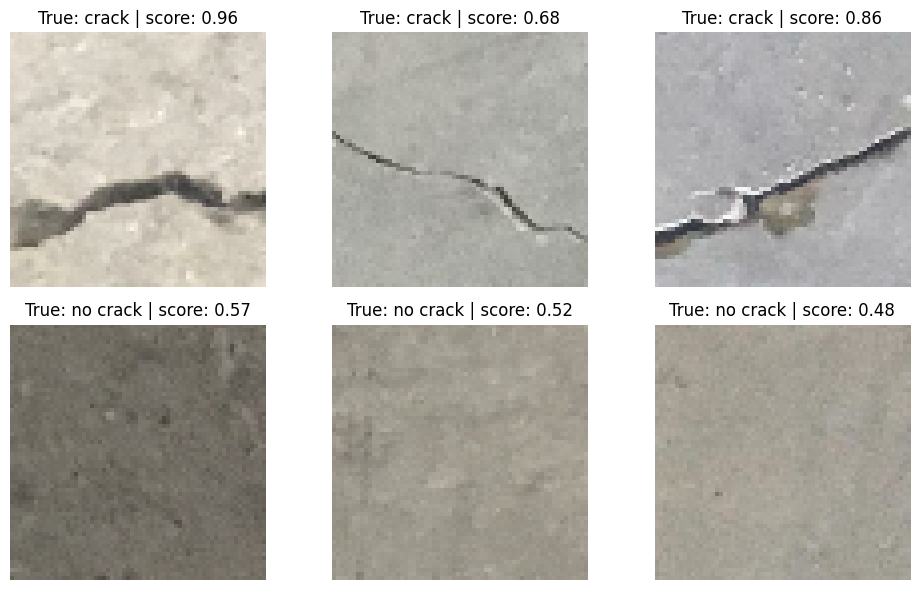

In [14]:
# Select actual validation images and run exactly the same pipeline as training.
preview_ds = make_dataset(val_paths[:6], y_val[:6])
preview_images, preview_labels = next(iter(preview_ds))
preview_scores = dense_model.predict(preview_images, verbose=0).ravel()
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for ax, image, actual, score in zip(axes.ravel(), preview_images, preview_labels, preview_scores):
    ax.imshow(tf.cast(tf.clip_by_value(image, 0, 255), tf.uint8).numpy())
    ax.set_title(f"True: {'crack' if actual.numpy() else 'no crack'} | score: {score:.2f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

> **Exercise 5:** Choose a different validation image. Print its crack score and the predicted label at threshold 0.50. Does the score agree with the visual evidence?

In [15]:
# To Do
# index = 12
# one_ds = make_dataset([val_paths[index]], [y_val[index]])
# ...

<details><summary>Solution to Exercise 5 (click to expand)</summary>

```python
index = 12
one_ds = make_dataset([val_paths[index]], [y_val[index]])
score = float(dense_model.predict(one_ds, verbose=0)[0, 0])
print("True label:", y_val[index], "Crack score:", round(score, 3))
print("Predicted label:", int(score >= 0.50))
```

</details>

## 7. Part VI – Mini Project: Compare Dense and Convolutional Models

A dense model flattens the image immediately. A CNN learns small local patterns before combining them. Build a compact CNN and train it for the **same eight epochs** on the same subset. Choose between the trained models using **validation accuracy**; break a tie with validation loss. Then evaluate that choice on the **test set once**.

For an inspection-related task, look beyond accuracy: **false negatives** (cracked images called uncracked) and **recall for cracked images** deserve particular attention. Your dataset labels indicate image appearance; they do not measure crack severity.

In [16]:
tf.keras.utils.set_random_seed(42)
cnn_model = Sequential([
    Input(shape=(64, 64, 3)), Rescaling(1.0 / 255),
    Conv2D(16, 3, activation="relu"), MaxPooling2D(),
    Conv2D(32, 3, activation="relu"), MaxPooling2D(),
    Flatten(), Dense(32, activation="relu"), Dense(1, activation="sigmoid"),
])
cnn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
cnn_history = cnn_model.fit(train_ds, validation_data=val_ds, epochs=8, verbose=2)
comparison = pd.DataFrame([
    {"model": "Dense", "validation_accuracy": dense_history.history["val_accuracy"][-1],
     "validation_loss": dense_history.history["val_loss"][-1], "parameters": dense_model.count_params()},
    {"model": "CNN", "validation_accuracy": cnn_history.history["val_accuracy"][-1],
     "validation_loss": cnn_history.history["val_loss"][-1], "parameters": cnn_model.count_params()},
])
print(comparison.round(3).to_string(index=False))
winner = comparison.sort_values(["validation_accuracy", "validation_loss"], ascending=[False, True]).iloc[0]["model"]
selected_model = dense_model if winner == "Dense" else cnn_model
print("Selected using validation data:", winner)

Epoch 1/8
38/38 - 7s - 182ms/step - accuracy: 0.7942 - loss: 0.4725 - val_accuracy: 0.9475 - val_loss: 0.1897
Epoch 2/8
38/38 - 9s - 239ms/step - accuracy: 0.9600 - loss: 0.1338 - val_accuracy: 0.9650 - val_loss: 0.1108
Epoch 3/8
38/38 - 5s - 143ms/step - accuracy: 0.9758 - loss: 0.0886 - val_accuracy: 0.9800 - val_loss: 0.0739
Epoch 4/8
38/38 - 4s - 99ms/step - accuracy: 0.9750 - loss: 0.0839 - val_accuracy: 0.9850 - val_loss: 0.0827
Epoch 5/8
38/38 - 5s - 129ms/step - accuracy: 0.9708 - loss: 0.0958 - val_accuracy: 0.9725 - val_loss: 0.0751
Epoch 6/8
38/38 - 5s - 133ms/step - accuracy: 0.9850 - loss: 0.0513 - val_accuracy: 0.9750 - val_loss: 0.0615
Epoch 7/8
38/38 - 4s - 109ms/step - accuracy: 0.9792 - loss: 0.0550 - val_accuracy: 0.9725 - val_loss: 0.0654
Epoch 8/8
38/38 - 5s - 132ms/step - accuracy: 0.9858 - loss: 0.0508 - val_accuracy: 0.9700 - val_loss: 0.0639
model  validation_accuracy  validation_loss  parameters
Dense                0.592            0.559      788609
  CNN    

Held-out test accuracy: 0.973; loss: 0.065
                  precision    recall  f1-score   support

No visible crack      0.948     1.000     0.973       200
   Visible crack      1.000     0.945     0.972       200

        accuracy                          0.973       400
       macro avg      0.974     0.972     0.972       400
    weighted avg      0.974     0.973     0.972       400

Cracked images called uncracked (false negatives): 11


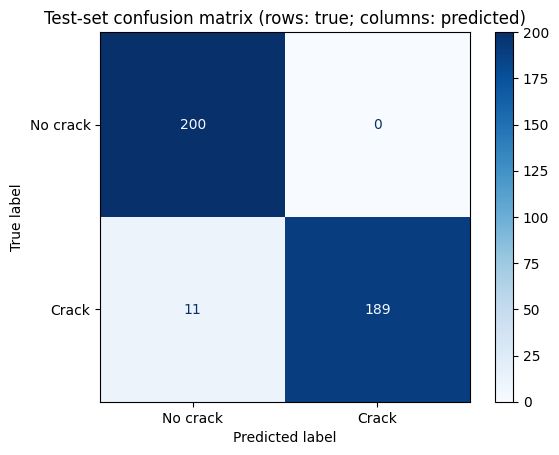

In [17]:
test_loss, test_accuracy = selected_model.evaluate(test_ds, verbose=0)
test_scores = selected_model.predict(test_ds, verbose=0).ravel()
test_predictions = (test_scores >= 0.50).astype(int)
y_test_array = np.asarray(y_test)
print(f"Held-out test accuracy: {test_accuracy:.3f}; loss: {test_loss:.3f}")
print(classification_report(y_test_array, test_predictions, labels=[0, 1],
                            target_names=["No visible crack", "Visible crack"],
                            digits=3, zero_division=0))
cm = confusion_matrix(y_test_array, test_predictions, labels=[0, 1])
print("Cracked images called uncracked (false negatives):", int(cm[1, 0]))
ConfusionMatrixDisplay(cm, display_labels=["No crack", "Crack"]).plot(cmap="Blues", values_format="d")
plt.title("Test-set confusion matrix (rows: true; columns: predicted)")
plt.show()

### 7.1 Examine an error image

Look at a misclassified test patch to form a concrete hypothesis about what might have misled the model. The error analysis comes **after** the one-time test report; do not repeatedly redesign the model based on these test images and keep claiming the same test score as an unbiased estimate.

True label: 1, predicted: 0, crack score: 0.390


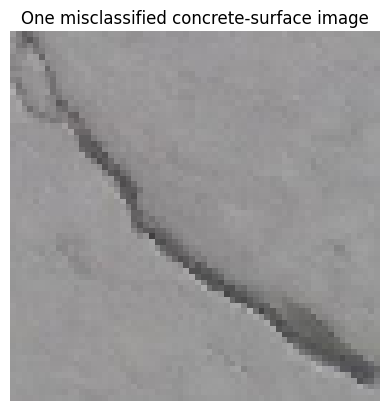

In [18]:
mistakes = np.flatnonzero(test_predictions != y_test_array)
if len(mistakes):
    idx = int(mistakes[0])
    print(f"True label: {y_test_array[idx]}, predicted: {test_predictions[idx]}, "
          f"crack score: {test_scores[idx]:.3f}")
    image = tf.keras.utils.load_img(test_paths[idx], target_size=IMAGE_SIZE)
    plt.imshow(image)
    plt.title("One misclassified concrete-surface image")
    plt.axis("off")
    plt.show()
else:
    print("No misclassified images in this test sample.")

## 8. Reflection and Extensions

1. Did the CNN outperform the dense model on **validation** images? What happened to training time and model size?
2. How many cracked test images were missed? How would that affect an engineer using the tool to prioritize visual review?
3. Which textures, shadows, or joints might cause false alarms? Inspect actual error images.
4. Try changing the image resolution or the classification threshold, using **validation** results to choose. What happens to crack recall and false alarms?
5. A crack/no-crack label says nothing about crack width, depth, load path, or cause. What additional inspection data would you require before a maintenance or safety decision?
6. The downloaded files are cropped patches. How might related patches from one original surface end up in both train and test sets? Propose an evaluation using entirely separate structures, inspection dates, or original photographs.

> **Key idea:** Keras can classify construction imagery with a small amount of code. A model that works on held-out patches may still struggle with new materials, lighting, cameras, or sites; use it as an aid to human inspection rather than an engineering judgment.

**Sources:** [Concrete Crack Images for Classification (Kaggle)](https://www.kaggle.com/datasets/arnavr10880/concrete-crack-images-for-classification) · [KaggleHub download documentation](https://github.com/Kaggle/kagglehub) · [Keras image-classification example](https://keras.io/examples/vision/image_classification_from_scratch/). The prose, exercises, and code in this lab are newly written for this course.